<a href="https://colab.research.google.com/github/Sreeja0308/skaithi_64061/blob/main/Assignment_3_Time_series_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-04-11 13:24:34--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.213.8, 52.217.236.192, 54.231.131.32, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.213.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  20.8MB/s    in 0.6s    

2026-04-11 13:24:35 (20.8 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [ ]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

line1 = data.split("\n")
header1 = line1[0].split(",")
line1 = line1[1:]
print(header1)
print(len(line1))

num_variables = len(header1)
print("Number of variables:", num_variables)
num_rows = len(line1)
print("Number of rows:", num_rows)

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451
Number of variables: 15
Number of rows: 420451


The temperature and raw_data arrays hold the specific values, so you can use them later for processing or analysis. Numbers separated by commas become floating-point values.

In [ ]:
import numpy as np
temp1 = np.zeros((len(line1),))
rawdata1 = np.zeros((len(line1), len(header1) - 1))
for i, line in enumerate(line1):
    values = [float(x) for x in line.split(",")[1:]]
    temp1[i] = values[1]
    rawdata1[i, :] = values[:]

Text(0, 0.5, 'Temperature')

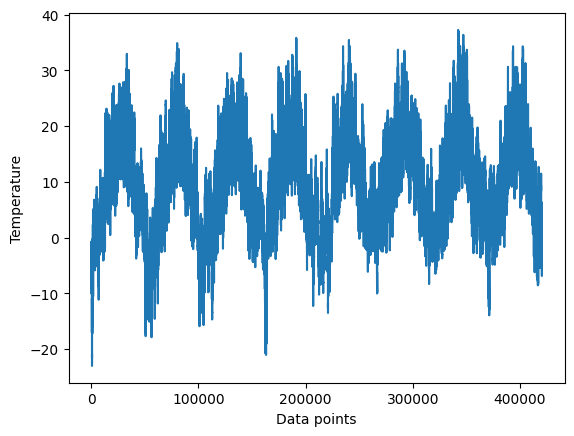

In [ ]:
from matplotlib import pyplot as plt
plt.plot(range(len(temp1)), temp1)
plt.xlabel('Data points')
plt.ylabel('Temperature')

The temperature chart is drawn for the first ten days. If you gather 144 data points each day, then over ten days you’ll collect 1,440 data points.

Text(0, 0.5, 'Temperature')

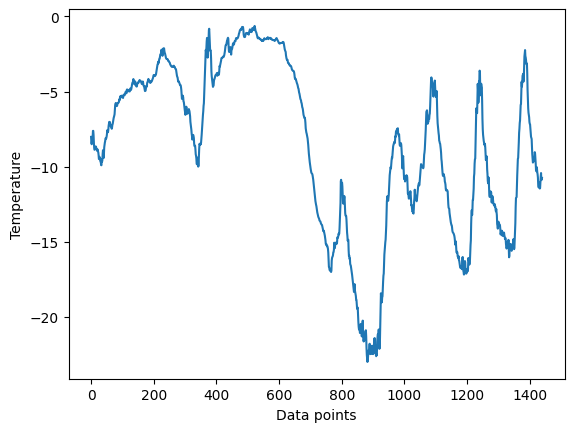

In [ ]:
plt.plot(range(1440), temp1[:1440])
plt.xlabel('Data points')
plt.ylabel('Temperature')

We need to decide how many samples go into each set: 50% for training and 25% for validation.

In [ ]:
num_of_train = int(0.5 * len(rawdata1))
num_of_validation= int(0.25 * len(rawdata1))
num_of_test= len(rawdata1) - num_of_train - num_of_validation
print("Number of train samples:", num_of_train)
print("Number of validation samples:", num_of_validation)
print("Number of test samples:", num_of_test)

Number of train samples: 210225
Number of validation samples: 105112
Number of test samples: 105114


Preparing the data

Data normalisation: Vectorisation is not required because the data is already numerically represented. All variables should be standardised, however, because the data scales are different—temperature ranges from -20 to +30, and pressure is measured in millibars.

In [ ]:
mean1 = rawdata1[:num_of_train].mean(axis=0)
rawdata1 -= mean1
std = rawdata1[:num_of_train].std(axis=0)
rawdata1 /= std

In [ ]:
import numpy as np
from tensorflow import keras
int_sequence1 = np.arange(10)
dummy_dataset1 = keras.utils.timeseries_dataset_from_array(
    data=int_sequence1[:-3],
    targets=int_sequence1[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset1:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


The development of training, validation, and testing datasets is crucial because to the substantial amount of duplication in the dataset's sample. It would be inefficient to explicitly allocate RAM for every sample. Rather, real-time sample generation will be used.

In [ ]:
sample_rate = 6
sequencelength = 120
delay = sample_rate * (sequencelength + 24 - 1)
batch_size = 256

training_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_of_train)

validation_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_of_train,
    end_index=num_of_train + num_of_validation)

testing_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_of_train + num_of_validation)

Generating the output of one of this datasets

In [ ]:
for samples, targets in training_data:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


A common-sense, non-machine-learning baseline

Finding the baseline of common sense MAE: The "evaluate_naive_method" function lays the groundwork for assessing the effectiveness of a straightforward forecasting technique that uses the last value in the input sequence to predict the value that will follow a given value.

In [ ]:
def evaluate_naive_method(dataset):
    total_absolute_error = 0.
    samples_saw = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean1[1]
        total_absolute_error += np.sum(np.abs(preds - targets))
        samples_saw += samples.shape[0]
    return total_absolute_error / samples_saw

print(f"Validation MAE: {evaluate_naive_method(validation_data):.2f}")
print(f"Test MAE: {evaluate_naive_method(testing_data):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


Predicting that the temperature will be the same 24 hours from now is a Common sense basilne approach. The validation mean absolute error (MAE) is 2.44 degrees Celsius whereas the test mean is 2.62 degrees Celsius utilizing this simple baseline. Stated otherwise, there would be an average variance of around 2.5 degrees if the future temperature were constant with the present one.

A basic machine-learning model - Dense Layer

Training and evaluating a densely connected model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
G1 = layers.Flatten()(inputs)
G1 = layers.Dense(16, activation="relu")(G1)
outputs = layers.Dense(1)(G1)
model = keras.Model(inputs, outputs)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras",
                                    save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


history = model.fit(training_data, epochs=20,
                    validation_data = validation_data, callbacks=callbacks)

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - loss: 12.0579 - mae: 2.7020 - val_loss: 11.3651 - val_mae: 2.6662
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 8.9172 - mae: 2.3488 - val_loss: 10.2687 - val_mae: 2.5185
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 8.1328 - mae: 2.2431 - val_loss: 10.4082 - val_mae: 2.5432
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 7.6533 - mae: 2.1744 - val_loss: 10.6358 - val_mae: 2.5826
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 7.3663 - mae: 2.1351 - val_loss: 10.4077 - val_mae: 2.5487
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - loss: 7.1146 - mae: 2.0979 - val_loss: 11.9820 - val_mae: 2.7358
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 6.9100 - mae: 2.0679 - val_loss: 10.7915 - val_mae: 2.5887
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 6.7810 - mae: 2.0490 - val_loss: 10.9079 - val_mae: 2.6040
Epoch 9/20
819/819 ━━━━━━━━━━━━

In [ ]:
model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 11.4404 - mae: 2.6613
Test MAE: 2.66


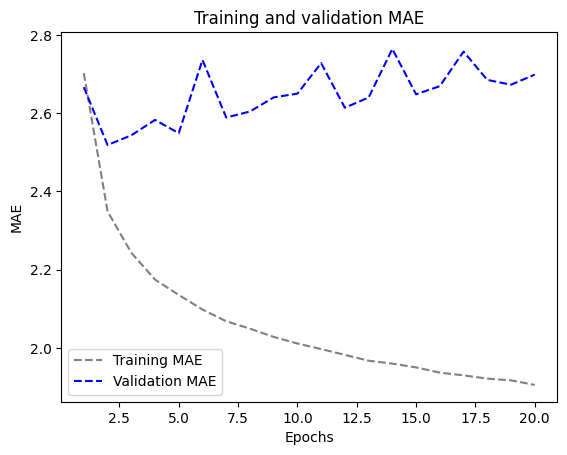

In [ ]:
import matplotlib.pyplot as plt
loss1 = history.history["mae"]
validation_loss = history.history["val_mae"]

epochs = range(1, len(loss1) + 1)
plt.figure()
plt.plot(epochs, loss1, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

Let's try a 1D convolutional model

In [ ]:
inputs = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history1D = model.fit(training_data,
                    epochs=10,
                    validation_data=validation_data,
                    callbacks=callbacks)

model_to_dot = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(testing_data)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - loss: 21.3077 - mae: 3.6234 - val_loss: 15.8721 - val_mae: 3.1692
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 15.3306 - mae: 3.1229 - val_loss: 14.3082 - val_mae: 2.9862
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 14.3349 - mae: 3.0181 - val_loss: 14.1874 - val_mae: 2.9736
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 13.6031 - mae: 2.9358 - val_loss: 14.1635 - val_mae: 2.9684
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 12.9489 - mae: 2.8619 - val_loss: 14.0563 - val_mae: 2.9522
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 12.4039 - mae: 2.7989 - val_loss: 14.4142 - val_mae: 2.9889
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 11.9580 - mae: 2.7485 - val_loss: 14.3417 - val_mae: 2.9827
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 11.6118 - mae: 2.7101 - val_loss: 13.8020 - val_mae: 2.9235
Epoch 9/10
819/819 ━━━━━

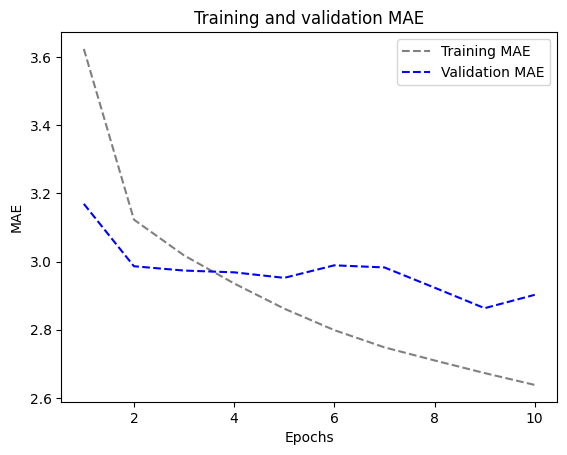

In [ ]:
import matplotlib.pyplot as plt
loss1D = history1D.history["mae"]
validation_loss1D = history1D.history["val_mae"]

epochs = range(1, len(loss1D) + 1)
plt.figure()
plt.plot(epochs, loss1D, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss1D, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

Dense models and common sense work better than convolutional data. That could be due to the fact that weather records don’t follow the rule of translation invariance. The way the information is presented matters a lot. Data from the recent past helps predict tomorrow’s temperature far better than information gathered days ahead. Unfortunately, a 1D convolutional neural network can’t capture this important sequence of time order well enough.

A Simple RNN

1. An RNN layer that can process sequences of any length

In [ ]:
the_features = 14
input_RNN = keras.Input(shape=(None, the_features))
x = layers.SimpleRNN(16)(input_RNN)
output_RNN = layers.Dense(1)(x)

models_RNN = keras.Model(input_RNN, output_RNN)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_SimRNN.keras",
                                    save_best_only=True)
]
models_RNN.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_RNN = models_RNN.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

models_RNN = keras.models.load_model("jena_SimRNN.keras")
print(f"Test MAE: {models_RNN.evaluate(testing_data)[1]:.2f}")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - loss: 41.5380 - mae: 4.7336 - val_loss: 12.5482 - val_mae: 2.6584
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 11.2019 - mae: 2.6022 - val_loss: 9.3693 - val_mae: 2.3775
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 10.4249 - mae: 2.5227 - val_loss: 9.0269 - val_mae: 2.3376
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 10.2470 - mae: 2.4995 - val_loss: 9.0488 - val_mae: 2.3370
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 10.1536 - mae: 2.4869 - val_loss: 8.9691 - val_mae: 2.3256
405/405 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 10.2949 - mae: 2.4819
Test MAE: 2.48


2. Simple RNN - Stacking RNN layers

In [ ]:
the_features2 = 14
steps = 120
inpu2 = keras.Input(shape=(steps, the_features2))
a = layers.SimpleRNN(16, return_sequences=True)(inpu2)
a = layers.SimpleRNN(16, return_sequences=True)(a)
outpu2 = layers.SimpleRNN(16)(a)
outpu2 = layers.Dense(1)(outpu2) # Added Dense layer to match target shape
models2 = keras.Model(inpu2, outpu2)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_SRNN2.keras",
                                    save_best_only=True)
]
models2.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history2 = models2.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

models2 = keras.models.load_model("jena_SRNN2.keras")
print(f"Test MAE: {models2.evaluate(testing_data)[1]:.2f}")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 71ms/step - loss: 39.6296 - mae: 4.5380 - val_loss: 12.5941 - val_mae: 2.6583
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 11.2376 - mae: 2.6037 - val_loss: 9.6270 - val_mae: 2.4038
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 10.4454 - mae: 2.5240 - val_loss: 9.6034 - val_mae: 2.4115
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 10.2651 - mae: 2.5030 - val_loss: 10.5870 - val_mae: 2.4928
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 10.1634 - mae: 2.4904 - val_loss: 9.2522 - val_mae: 2.3631
405/405 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - loss: 10.2980 - mae: 2.4975
Test MAE: 2.50


A Simple GRU (Gated Recurrent Unit)

In [ ]:
inputs_GRU = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
b = layers.GRU(16)(inputs_GRU)
outputs_GRU = layers.Dense(1)(b)
models_GRU = keras.Model(inputs_GRU, outputs_GRU)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru.keras",
                                    save_best_only=True)
]
models_GRU.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_GRU = models_GRU.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

models_GRU = keras.models.load_model("jena_gru.keras")
print(f"Test MAE: {models_GRU.evaluate(testing_data)[1]:.2f}")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - loss: 44.2494 - mae: 4.8528 - val_loss: 13.2446 - val_mae: 2.7166
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 10.7138 - mae: 2.5438 - val_loss: 9.1653 - val_mae: 2.3399
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 9.5353 - mae: 2.4130 - val_loss: 8.9499 - val_mae: 2.3246
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - loss: 9.2429 - mae: 2.3763 - val_loss: 9.0728 - val_mae: 2.3335
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 9.0130 - mae: 2.3465 - val_loss: 8.8596 - val_mae: 2.3183
405/405 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - loss: 9.8616 - mae: 2.4762
Test MAE: 2.48


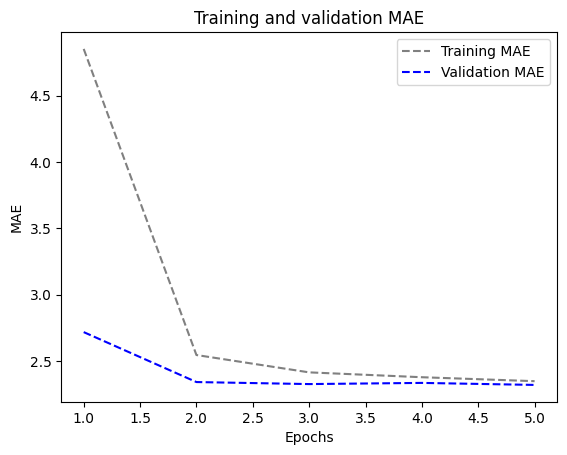

In [ ]:
import matplotlib.pyplot as plt
loss_GRU = history_GRU.history["mae"]
validation_loss_GRU = history_GRU.history["val_mae"]

epochs = range(1, len(loss_GRU) + 1)
plt.figure()
plt.plot(epochs, loss_GRU, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_GRU, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

LSTM(Long Short-Term Memory )

1. LSTM-Simple

In [ ]:
inputs_LSTMS = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
c = layers.LSTM(16)(inputs_LSTMS)
output_LSTMS = layers.Dense(1)(c)
model_LSTMS = keras.Model(inputs_LSTMS, output_LSTMS)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
]
model_LSTMS.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_LSTMS = model_LSTMS.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - loss: 39.7576 - mae: 4.5670 - val_loss: 13.2577 - val_mae: 2.7156
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 10.8007 - mae: 2.5543 - val_loss: 10.7417 - val_mae: 2.4730
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 9.7306 - mae: 2.4358 - val_loss: 9.9826 - val_mae: 2.4406
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 9.2428 - mae: 2.3780 - val_loss: 9.4668 - val_mae: 2.3951
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 8.8733 - mae: 2.3301 - val_loss: 9.5794 - val_mae: 2.4033


In [ ]:
model_LSTMS = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model_LSTMS.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 10.2254 - mae: 2.5196
Test MAE: 2.52


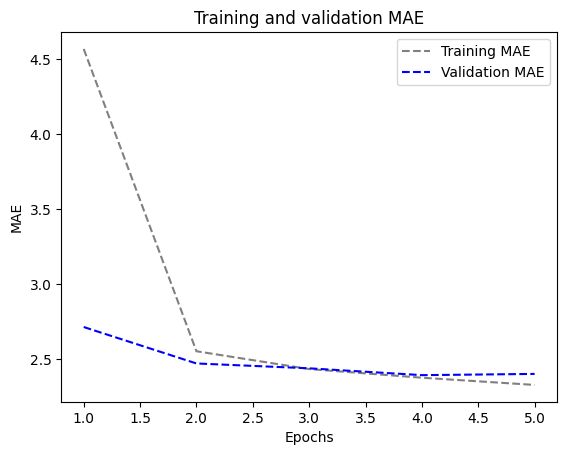

In [ ]:
import matplotlib.pyplot as plt
loss_LSTMS = history_LSTMS.history["mae"]
validation_loss_LSTMS = history_LSTMS.history["val_mae"]

epochs = range(1, len(loss_LSTMS) + 1)
plt.figure()
plt.plot(epochs, loss_LSTMS, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_LSTMS, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

2. LSTM - dropout Regularization

In [ ]:
input_LSTMR = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
d = layers.LSTM(16, recurrent_dropout=0.25)(input_LSTMR )
d = layers.Dropout(0.5)(d)
output_LSTMR = layers.Dense(1)(d)
model_LSTMR = keras.Model(input_LSTMR , output_LSTMR )

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras",
                                    save_best_only=True)
]
model_LSTMR.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_LSTMR = model_LSTMR.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 326s 394ms/step - loss: 46.8025 - mae: 5.1153 - val_loss: 13.0230 - val_mae: 2.7172
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 323s 395ms/step - loss: 20.0005 - mae: 3.4312 - val_loss: 9.7326 - val_mae: 2.4249
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 322s 393ms/step - loss: 18.3191 - mae: 3.2935 - val_loss: 9.2870 - val_mae: 2.3739
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 322s 393ms/step - loss: 17.4776 - mae: 3.2190 - val_loss: 9.1856 - val_mae: 2.3599
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 323s 394ms/step - loss: 16.8484 - mae: 3.1612 - val_loss: 9.1485 - val_mae: 2.3478


In [ ]:
model_LSTMR = keras.models.load_model("jena_lstm_dropout.keras")
print(f"Test MAE: {model_LSTMR.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 45s 108ms/step - loss: 10.6865 - mae: 2.5632
Test MAE: 2.56


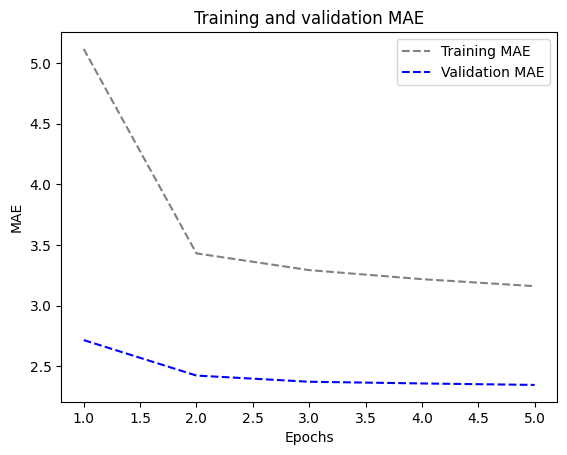

In [ ]:
import matplotlib.pyplot as plt
loss_LSTMR = history_LSTMR .history["mae"]
validation_loss_LSTMR = history_LSTMR .history["val_mae"]

epochs = range(1, len(loss_LSTMR) + 1)
plt.figure()
plt.plot(epochs, loss_LSTMR, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_LSTMR, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

3. LSTM - Stacked setup with 16 units

In [ ]:
input_16 = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
e = layers.LSTM(16, return_sequences=True)(input_16)
e = layers.LSTM(16)(e)
output_16 = layers.Dense(1)(e)
model_16 = keras.Model(input_16, output_16)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_LSTM_stacked1.keras",
                                    save_best_only=True)
]
model_16.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_16 = model_16.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - loss: 42.3972 - mae: 4.7345 - val_loss: 13.6592 - val_mae: 2.7770
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 10.3376 - mae: 2.4874 - val_loss: 9.8493 - val_mae: 2.4353
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 8.5963 - mae: 2.2840 - val_loss: 10.0513 - val_mae: 2.4647
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.8670 - mae: 2.1822 - val_loss: 10.5933 - val_mae: 2.5551
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.3412 - mae: 2.1082 - val_loss: 11.1615 - val_mae: 2.6047


In [ ]:
model_16 = keras.models.load_model("jena_LSTM_stacked1.keras")
print(f"Test MAE: {model_16.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 10.9022 - mae: 2.5700
Test MAE: 2.57


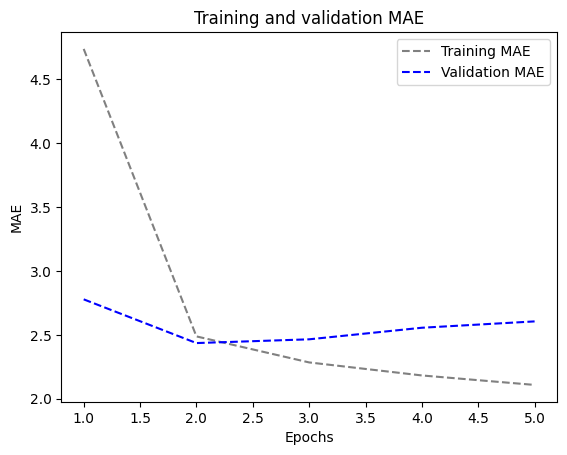

In [ ]:
import matplotlib.pyplot as plt
loss_16 = history_16.history["mae"]
validation_loss_16 = history_16.history["val_mae"]

epochs = range(1, len(loss_16) + 1)
plt.figure()
plt.plot(epochs, loss_16, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_16, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

4. LSTM - Stacked setup with 32 units

In [ ]:
input_32 = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
f = layers.LSTM(32, return_sequences=True)(input_32)
f = layers.LSTM(32)(f)
output_32 = layers.Dense(1)(f)
model_32 = keras.Model(input_32, output_32)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_LSTM_stacked2.keras",
                                    save_best_only=True)
]
model_32.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_32 = model_32.fit(training_data,
                    epochs=10,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 21.4150 - mae: 3.3028 - val_loss: 9.8178 - val_mae: 2.4539
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.9902 - mae: 2.1966 - val_loss: 10.4125 - val_mae: 2.5538
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 6.4377 - mae: 1.9664 - val_loss: 11.3863 - val_mae: 2.6647
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 5.4655 - mae: 1.8086 - val_loss: 11.8400 - val_mae: 2.6931
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - loss: 4.7754 - mae: 1.6866 - val_loss: 11.7339 - val_mae: 2.7014
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 4.1611 - mae: 1.5711 - val_loss: 12.5962 - val_mae: 2.7812
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 3.7699 - mae: 1.4892 - val_loss: 12.3772 - val_mae: 2.7638
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 3.3483 - mae: 1.4035 - val_loss: 13.2648 - val_mae: 2.8426
Epoch 9/10
819/819 ━━━━━━━━━━━━━

In [ ]:
model_32 = keras.models.load_model("jena_LSTM_stacked2.keras")
print(f"Test MAE: {model_32.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 11.1665 - mae: 2.6138
Test MAE: 2.61


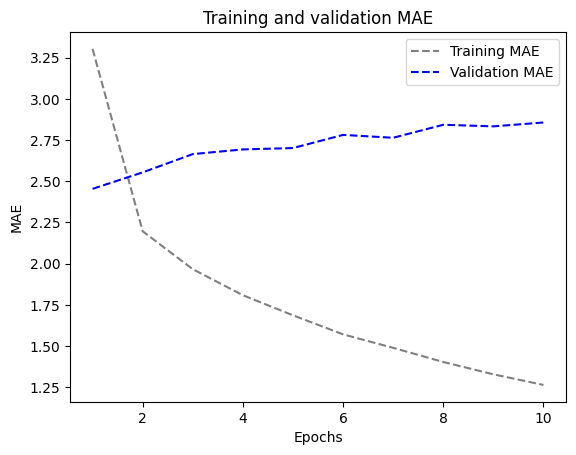

In [ ]:
import matplotlib.pyplot as plt
loss_32 = history_32.history["mae"]
validation_loss_32 = history_32.history["val_mae"]

epochs = range(1, len(loss_32) + 1)
plt.figure()
plt.plot(epochs, loss_32, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_32, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

5. LSTM - Stacked setup with 8 units

In [ ]:
input_8u = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
h = layers.LSTM(8, return_sequences=True)(input_8u)
h = layers.LSTM(8)(h)
output_8u = layers.Dense(1)(h)
model_8u = keras.Model(input_8u, output_8u)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_LSTM_stacked3.keras",
                                    save_best_only=True)
]
model_8u.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_8u = model_8u.fit(training_data,
                    epochs=10,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 65ms/step - loss: 77.6246 - mae: 6.7761 - val_loss: 40.4925 - val_mae: 4.7317
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 23.8209 - mae: 3.5910 - val_loss: 14.0335 - val_mae: 2.7868
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 11.6790 - mae: 2.6288 - val_loss: 9.9321 - val_mae: 2.4302
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 9.9315 - mae: 2.4504 - val_loss: 10.1292 - val_mae: 2.4690
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 9.5013 - mae: 2.4004 - val_loss: 9.8222 - val_mae: 2.4234
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 66ms/step - loss: 9.2723 - mae: 2.3738 - val_loss: 10.5846 - val_mae: 2.5429
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 9.1165 - mae: 2.3533 - val_loss: 9.8215 - val_mae: 2.4340
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 8.9781 - mae: 2.3372 - val_loss: 9.8271 - val_mae: 2.4357
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

In [ ]:
model_8u = keras.models.load_model("jena_LSTM_stacked3.keras")
print(f"Test MAE: {model_8u.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 10.3414 - mae: 2.4999
Test MAE: 2.50


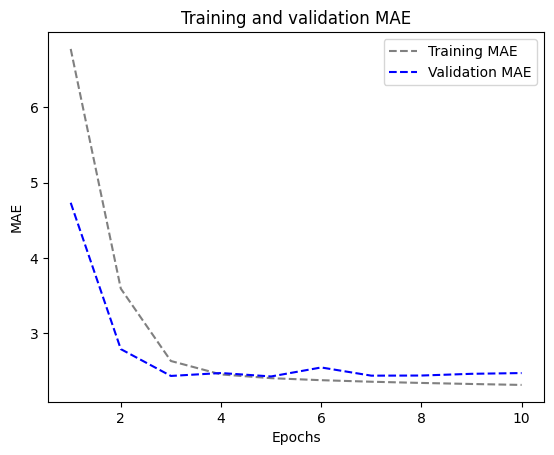

In [ ]:
import matplotlib.pyplot as plt
loss_8u = history_8u.history["mae"]
validation_loss_8u = history_8u.history["val_mae"]

epochs = range(1, len(loss_8u) + 1)
plt.figure()
plt.plot(epochs, loss_8u, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_8u, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

6. LSTM - dropout-regularized, stacked model

In [38]:
import os
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import subprocess

# --- Start of added code for data loading and preprocessing ---
file_path = os.path.join("/content", "jena_climate_2009_2016.csv")
zip_path = os.path.join("/content", "jena_climate_2009_2016.csv.zip")

# Check if the CSV file exists, if not, download and unzip
if not os.path.exists(file_path):
    print("Jena climate data not found. Attempting to download and unzip...")
    try:
        # Download the zip file if it doesn't exist
        if not os.path.exists(zip_path):
            print("Downloading jena_climate_2009_2016.csv.zip...")
            subprocess.run(["wget", "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip", "-P", "/content/"], check=True)
            print("Download complete.")

        # Unzip the file
        print("Unzipping jena_climate_2009_2016.csv.zip...")
        subprocess.run(["unzip", "-o", zip_path, "-d", "/content/"], check=True) # -o for overwrite, -d for directory
        print("Unzip complete. Data file should now be available.")
    except subprocess.CalledProcessError as e:
        print(f"Error during data download or unzip: {e}")
        # Re-raise the exception or handle appropriately if you want the cell to stop here
        raise

fname = file_path # Use the verified file path

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]

temp1 = np.zeros((len(lines),))
rawdata1 = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temp1[i] = values[1]
    rawdata1[i, :] = values[:]

num_of_train = int(0.5 * len(rawdata1))
num_of_validation = int(0.25 * len(rawdata1))
num_of_test = len(rawdata1) - num_of_train - num_of_validation

mean1 = rawdata1[:num_of_train].mean(axis=0)
rawdata1 -= mean1
std = rawdata1[:num_of_train].std(axis=0)
rawdata1 /= std

sample_rate = 6
sequencelength = 120
delay = sample_rate * (sequencelength + 24 - 1)
batch_size = 256

training_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_of_train)

validation_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_of_train,
    end_index=num_of_train + num_of_validation)

testing_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_of_train + num_of_validation)
# --- End of added code for data loading and preprocessing ---

inputs = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
i = layers.LSTM(8, recurrent_dropout=0.5, return_sequences=True)(inputs)
i = layers.LSTM(8, recurrent_dropout=0.5)(i)
i = layers.Dropout(0.5)(i)
outputs = layers.Dense(1)(i)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_stacked_LSTM_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(training_data,
                    epochs=10,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 648s 786ms/step - loss: 76.2509 - mae: 6.7446 - val_loss: 34.4494 - val_mae: 4.3691
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 651s 794ms/step - loss: 31.7564 - mae: 4.2212 - val_loss: 13.9815 - val_mae: 2.7891
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 637s 777ms/step - loss: 24.3892 - mae: 3.7417 - val_loss: 11.0106 - val_mae: 2.5316
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 690s 786ms/step - loss: 22.3870 - mae: 3.5953 - val_loss: 10.6889 - val_mae: 2.5192
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 633s 773ms/step - loss: 21.2053 - mae: 3.5028 - val_loss: 10.0868 - val_mae: 2.4495
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 624s 762ms/step - loss: 20.3805 - mae: 3.4327 - val_loss: 10.1406 - val_mae: 2.4606
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 626s 763ms/step - loss: 19.4554 - mae: 3.3558 - val_loss: 9.7437 - val_mae: 2.4139
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 623s 761ms/step - loss: 18.7726 - mae: 3.3049 - val_loss: 9.4139 - val_mae: 2.3815
Epoch 9/10

In [ ]:
model_r = keras.models.load_model("jena_stacked_LSTM_dropout.keras")
print(f"Test MAE: {model_r.evaluate(testing_data)[1]:.2f}")

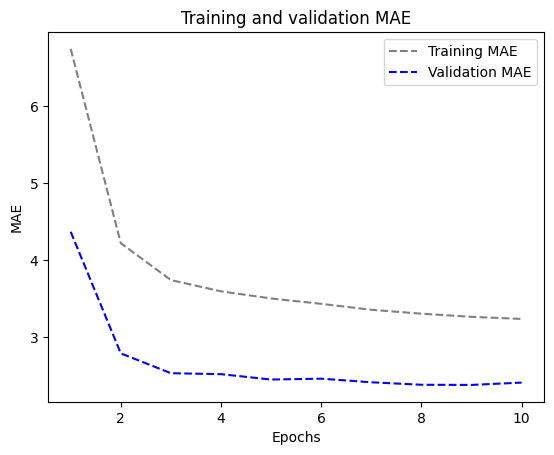

In [39]:
import matplotlib.pyplot as plt
loss_r = history.history["mae"]
validation_loss_r = history.history["val_mae"]

epochs = range(1, len(loss_r) + 1)
plt.figure()
plt.plot(epochs, loss_r, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_r, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

Bidirectional LSTM

In [40]:
inputs = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_bidirec_LSTM.keras",
                                    save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history.bi = model.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                     callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - loss: 29.7125 - mae: 3.9054 - val_loss: 10.8030 - val_mae: 2.5570
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 9.6550 - mae: 2.4193 - val_loss: 9.9659 - val_mae: 2.4409
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 8.6170 - mae: 2.2840 - val_loss: 9.5465 - val_mae: 2.3869
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.9980 - mae: 2.1999 - val_loss: 9.6559 - val_mae: 2.4129
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.5740 - mae: 2.1416 - val_loss: 10.0000 - val_mae: 2.4507


In [41]:
model_bi = keras.models.load_model("jena_bidirec_LSTM.keras")
print(f"Test MAE: {model_bi.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - loss: 10.3474 - mae: 2.5373
Test MAE: 2.54


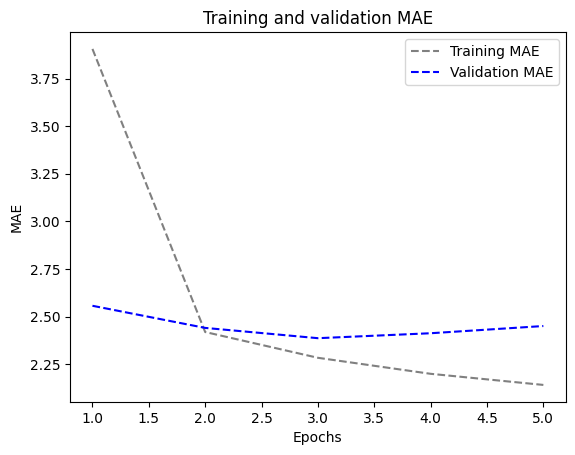

In [42]:
import matplotlib.pyplot as plt
loss_bi = history.bi.history["mae"]
validation_loss_bi = history.bi.history["val_mae"]

epochs = range(1, len(loss_bi) + 1)
plt.figure()
plt.plot(epochs, loss_bi, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_bi, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

1D Convnets and LSTM togther

In [43]:
input_final = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
l = layers.Conv1D(64, 3, activation='relu')(input_final)
l = layers.MaxPooling1D(3)(l)
l = layers.Conv1D(128, 3, activation='relu')(l)
l = layers.GlobalMaxPooling1D()(l)
l = layers.Reshape((-1, 128))(l)  # Reshape the data to be 3D
l = layers.LSTM(16)(l)
output_final = layers.Dense(1)(l)
model_final = keras.Model(input_final, output_final)

model_final.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_Conv_LSTM.keras", save_best_only=True)
]

history_final = model_final.fit(training_data, epochs=5, validation_data=validation_data, callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - loss: 53.0573 - mae: 5.4722 - val_loss: 26.6440 - val_mae: 3.9876
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 17.8176 - mae: 3.2603 - val_loss: 21.7653 - val_mae: 3.7055
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 14.3596 - mae: 2.9490 - val_loss: 21.8015 - val_mae: 3.6833
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 12.7544 - mae: 2.7729 - val_loss: 24.2189 - val_mae: 3.8326
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 11.6562 - mae: 2.6395 - val_loss: 27.7304 - val_mae: 4.1132
